# Práctico 3 — Herramientas estadísticas
**Análisis de Datos**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statistics import median
%matplotlib inline

In [2]:
# Estadísticos muestrales reutilizables
def media(d): return sum(d)/len(d)

def var_m(d):
    m = media(d)
    return sum((x-m)**2 for x in d)/(len(d)-1)

def std_m(d): return var_m(d)**0.5

def cov(xs, ys):
    mx, my = media(xs), media(ys)
    return sum((x-mx)*(y-my) for x,y in zip(xs,ys))/(len(xs)-1)

def corr(xs, ys): return cov(xs,ys)/(std_m(xs)*std_m(ys))

## Bloque 1 — Preguntas conceptuales (Ejercicios 1–4)

### Ejercicio 1 — Encuesta universitaria sobre tiempo en internet
**a)** **Población:** todos los estudiantes de la universidad.

**b)** **Muestra:** los estudiantes seleccionados que respondieron la encuesta.

### Ejercicio 2 — Tienda de alimentación
**a) Estadística descriptiva:** ¿Cuál fue el producto más vendido el último mes?

**c) Relación entre variables:** ¿Existe relación entre el día de la semana y el volumen de ventas?

**d) Predicción:** ¿Cuántos kg de pan se venderán la próxima semana dado el historial de ventas?

### Ejercicio 3 — Encuesta a aficionados de básquetbol
| Pregunta | Tipo | Subtipo |
|---|---|---|
| a) ¿Tiene entrada de temporada? | Categórica | Nominal (Sí/No) |
| b) ¿Vive en el estado de Orange? | Categórica | Nominal (Sí/No) |
| c) ¿Cuánto costó la entrada? | Numérica | Continua |
| d) Nivel de satisfacción | Categórica | Ordinal |

### Ejercicio 4 — Encuesta en heladería
| Pregunta | Tipo |
|---|---|
| a) ¿Sabor favorito? | Categórica (nominal) |
| b) ¿Veces al mes que toma helado? | Numérica discreta |
| c) ¿Tiene hijos menores de 10 años? | Categórica (nominal – Sí/No) |
| d) ¿Ha probado el último sabor? | Categórica (nominal – Sí/No) |

## Bloque 2 — Estadística descriptiva (Ejercicios 5–14)

### Ejercicio 5 — Cruceros al Caribe

In [3]:
d5 = [20, 73, 75, 80, 82]

media5   = media(d5)
mediana5 = median(sorted(d5))
# No hay moda: todos los valores son distintos

print(f'Media   = {media5:.2f}')
print(f'Mediana = {mediana5}')
print('Moda    = no existe (todos los valores son únicos)')
print()
print('→ La mediana (75) describe mejor los datos:'
      ' el valor 20 es atípico y arrastra la media hacia abajo.')

Media   = 66.00
Mediana = 75
Moda    = no existe (todos los valores son únicos)

→ La mediana (75) describe mejor los datos: el valor 20 es atípico y arrastra la media hacia abajo.


### Ejercicio 6 — Reclamaciones en grandes almacenes

In [4]:
d6 = [13, 15, 8, 16, 8]

media6   = media(d6)
mediana6 = median(sorted(d6))
moda6    = 8  # aparece dos veces

print(f'a) Media   = {media6:.2f}')
print(f'b) Mediana = {mediana6}')
print(f'c) Moda    = {moda6}')

a) Media   = 12.00
b) Mediana = 13
c) Moda    = 8


### Ejercicio 7 — Pluses de altos ejecutivos

In [5]:
d7 = [15.8, 17.3, 28.4, 18.2, 15.0, 24.7, 13.1, 10.2, 29.3, 34.7, 16.9, 25.3]

mediana7 = median(sorted(d7))
media7   = media(d7)

print(f'a) Mediana muestral = {mediana7:.2f}%')
print(f'b) Media muestral   = {media7:.4f}%')

a) Mediana muestral = 17.75%
b) Media muestral   = 20.7417%


### Ejercicio 8 — Varianza y desviación estándar

In [6]:
d8 = [6, 8, 7, 10, 3, 5, 9, 8]

v8 = var_m(d8)
s8 = std_m(d8)

print(f'Varianza muestral s²  = {v8:.4f}')
print(f'Desviación estándar s = {s8:.4f}')

Varianza muestral s²  = 5.1429
Desviación estándar s = 2.2678


### Ejercicio 9 — Coeficiente de variación

In [7]:
d9 = [10, 8, 11, 7, 9]

# CV = (s / media) * 100
cv9 = (std_m(d9) / media(d9)) * 100

print(f'CV = {cv9:.4f}%')
print('→ CV bajo: datos muy concentrados alrededor de la media (9).')

CV = 17.5682%
→ CV bajo: datos muy concentrados alrededor de la media (9).


### Ejercicio 10 — Media simple vs. media ponderada

In [8]:
xi = [4.6, 3.2, 5.4, 2.6, 5.2]
wi = [8, 3, 6, 2, 5]

media10s = media(xi)
media10p = sum(x*w for x,w in zip(xi,wi)) / sum(wi)

print(f'a) Media aritmética simple = {media10s:.4f}')
print(f'b) Media ponderada         = {media10p:.4f}')

a) Media aritmética simple = 4.2000
b) Media ponderada         = 4.5833


### Ejercicio 11 — Distribución de frecuencias (40 observaciones)

In [9]:
# Punto medio de cada clase
clases11 = [(0,4),(5,9),(10,14),(15,19),(20,24)]
frec11   = [5, 8, 11, 9, 7]
mc11     = [(a+b)/2 for a,b in clases11]
n11      = sum(frec11)

media11 = sum(m*f for m,f in zip(mc11,frec11)) / n11
var11   = sum(f*(m-media11)**2 for m,f in zip(mc11,frec11)) / (n11-1)
std11   = var11**0.5

print(f'a) Media muestral       = {media11:.4f}')
print(f'b) Varianza muestral s² = {var11:.4f}')
print(f'   Desviación estándar  = {std11:.4f}')

a) Media muestral       = 12.6250
b) Varianza muestral s² = 41.2660
   Desviación estándar  = 6.4239


### Ejercicio 12 — Renta per cápita ponderada (7 estados EE.UU.)

In [10]:
pob = [4500752, 8684715, 12653544, 6195643, 19190115, 12365455, 5841748]
ing = [26338, 29442, 33690, 28783, 36574, 31998, 28455]

# Media ponderada por población
media12 = sum(p*i for p,i in zip(pob,ing)) / sum(pob)

print(f'Media ponderada per cápita = ${media12:,.2f}')

Media ponderada per cápita = $32,299.52


### Ejercicio 13 — Defectos en radios portátiles

In [11]:
defectos = [0, 1, 2, 3]
radios   = [12, 15, 17, 6]
n13      = sum(radios)

media13 = sum(d*r for d,r in zip(defectos,radios)) / n13
var13   = sum(r*(d-media13)**2 for d,r in zip(defectos,radios)) / (n13-1)
std13   = var13**0.5

print(f'Desviación estándar s = {std13:.4f}')

Desviación estándar s = 0.9817


### Ejercicio 14 — Horas de estudio (25 estudiantes)

In [12]:
clases14 = [(0,4),(4,8),(8,12),(12,16),(16,20)]
frec14   = [3, 7, 8, 5, 2]
mc14     = [(a+b)/2 for a,b in clases14]
n14      = sum(frec14)

media14 = sum(m*f for m,f in zip(mc14,frec14)) / n14
var14   = sum(f*(m-media14)**2 for m,f in zip(mc14,frec14)) / (n14-1)
std14   = var14**0.5

print(f'a) Media estimada        = {media14:.4f} horas')
print(f'b) Desviación estándar   = {std14:.4f} horas')

a) Media estimada        = 9.3600 horas
b) Desviación estándar   = 4.5724 horas


## Bloque 3 — Covarianza y correlación (Ejercicios 15–17)

### Ejercicio 15 — Seis pares (x, y)

In [13]:
pares15 = [(1,5),(3,7),(4,6),(3,6),(5,7),(5,8)]
x15, y15 = zip(*pares15)

cov15  = cov(x15, y15)
corr15 = corr(x15, y15)

print(f'a) Covarianza   s_xy = {cov15:.4f}')
print(f'b) Correlación  r    = {corr15:.4f}')
print('→ Correlación positiva moderada-fuerte: a mayor x, mayor y.')

a) Covarianza   s_xy = 1.3000
b) Correlación  r    = 0.8173
→ Correlación positiva moderada-fuerte: a mayor x, mayor y.


### Ejercicio 16 — Medicamento y recuperación de rodilla

In [14]:
pares16 = [
    (5,53),(4,56),(9,54),(14,56),(21,65),(7,53),(7,56),(9,59),
    (14,48),(11,66),(21,57),(17,49),(9,53),(21,52),(4,56),(9,46),(14,66),(13,49)
]
x16, y16 = zip(*pares16)

cov16  = cov(x16, y16)
corr16 = corr(x16, y16)

print(f'a) Covarianza   s_xy = {cov16:.4f}')
print(f'b) Correlación  r    = {corr16:.4f}')
print()
print('c) Análisis:')
print(f'   r ≈ {corr16:.2f}: relación lineal casi nula.')
print('   No se puede recomendar una dosis óptima solo con correlación.')
print('   Se requiere un análisis más profundo (regresión, más datos).')

a) Covarianza   s_xy = 4.2680
b) Correlación  r    = 0.1284

c) Análisis:
   r ≈ 0.13: relación lineal casi nula.
   No se puede recomendar una dosis óptima solo con correlación.
   Se requiere un análisis más profundo (regresión, más datos).


### Ejercicio 17 — Tarifas de envío Acme Delivery

In [15]:
pares17 = [
    (3,7),(3,6),(3,5),(5,5),(10,2),(3,9),(5,6),(10,5),
    (5,6),(10,1),(3,10),(5,7),(10,4),(5,6),(10,4)
]
x17, y17 = zip(*pares17)

cov17  = cov(x17, y17)
corr17 = corr(x17, y17)

print(f'a) Covarianza   s_xy = {cov17:.4f}')
print(f'   Correlación  r    = {corr17:.4f}')
print()
print('b) Análisis:')
print(f'   r ≈ {corr17:.2f}: correlación negativa fuerte.')
print('   El servicio superurgente ($10) entrega en 1-4 días vs 5-10 del ordinario ($3).')
print('   El precio más alto está justificado para envíos urgentes.')

a) Covarianza   s_xy = -5.5000
   Correlación  r    = -0.7760

b) Análisis:
   r ≈ -0.78: correlación negativa fuerte.
   El servicio superurgente ($10) entrega en 1-4 días vs 5-10 del ordinario ($3).
   El precio más alto está justificado para envíos urgentes.


## Bloque 4 — Distribuciones de probabilidad (Ejercicios 18–24)

### Ejercicio 18 — Computadores vendidos por día

In [16]:
x18 = [0,1,2,3,4,5,6]
p18 = [0.05,0.10,0.20,0.20,0.20,0.15,0.10]

# Suma de P(x) para cada condición
def P(xs, ps, cond): return sum(p for x,p in zip(xs,ps) if cond(x))

print(f'a) P(3 ≤ x ≤ 6) = {P(x18,p18, lambda x: 3<=x<=6):.2f}')
print(f'b) P(x > 3)     = {P(x18,p18, lambda x: x>3):.2f}')
print(f'c) P(x ≤ 4)     = {P(x18,p18, lambda x: x<=4):.2f}')
print(f'd) P(2 < x ≤ 5) = {P(x18,p18, lambda x: 2<x<=5):.2f}')

a) P(3 ≤ x ≤ 6) = 0.65
b) P(x > 3)     = 0.45
c) P(x ≤ 4)     = 0.75
d) P(2 < x ≤ 5) = 0.55


### Ejercicio 19 — Llegadas a estación de tren por hora

In [17]:
x19 = [0,1,2,3,4,5]
p19 = [0.10,0.15,0.20,0.25,0.20,0.10]

print(f'a) P(x ≥ 2)     = {P(x19,p19, lambda x: x>=2):.2f}')
print(f'b) P(x > 3)     = {P(x19,p19, lambda x: x>3):.2f}')
print(f'c) P(x ≤ 4)     = {P(x19,p19, lambda x: x<=4):.2f}')
print(f'd) P(1 ≤ x ≤ 3) = {P(x19,p19, lambda x: 1<=x<=3):.2f}')

a) P(x ≥ 2)     = 0.75
b) P(x > 3)     = 0.30
c) P(x ≤ 4)     = 0.90
d) P(1 ≤ x ≤ 3) = 0.60


### Ejercicio 20 — Devoluciones de autos

c) E(X)   = 1.2500
d) Var(X) = 1.1675


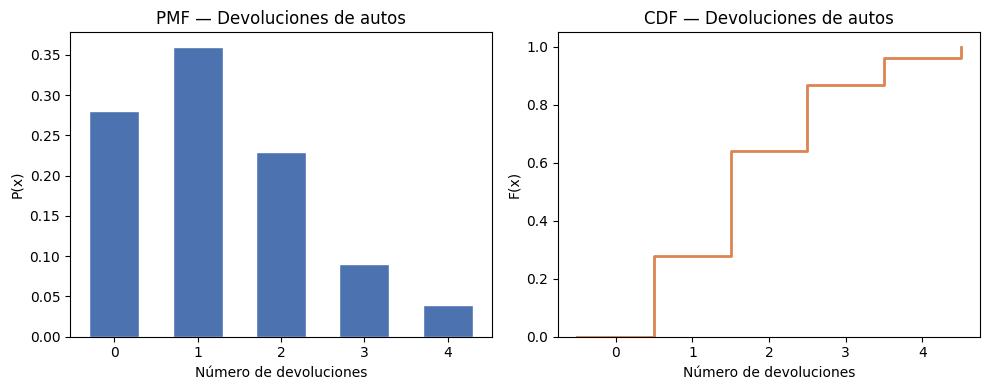

In [18]:
x20 = [0,1,2,3,4]
p20 = [0.28,0.36,0.23,0.09,0.04]
cdf20 = list(np.cumsum(p20))

# Esperanza y varianza
E20  = sum(x*p for x,p in zip(x20,p20))
V20  = sum(p*(x-E20)**2 for x,p in zip(x20,p20))

print(f'c) E(X)   = {E20:.4f}')
print(f'd) Var(X) = {V20:.4f}')

# Gráfico PMF
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(x20, p20, color='#4C72B0', edgecolor='white', width=0.6)
axes[0].set_xlabel('Número de devoluciones')
axes[0].set_ylabel('P(x)')
axes[0].set_title('PMF — Devoluciones de autos')
axes[0].set_xticks(x20)

# Gráfico CDF (escalera)
axes[1].step([x-0.5 for x in x20]+[x20[-1]+0.5], [0]+cdf20,
             where='post', color='#DD8452', linewidth=2)
axes[1].set_xlabel('Número de devoluciones')
axes[1].set_ylabel('F(x)')
axes[1].set_title('CDF — Devoluciones de autos')
axes[1].set_xticks(x20)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Ejercicio 21 — Pedidos de calderas nuevas

c) P(X ≥ 3)     = 0.50
d) E(X)          = 2.4500
e) Desv. típica  = 1.3592


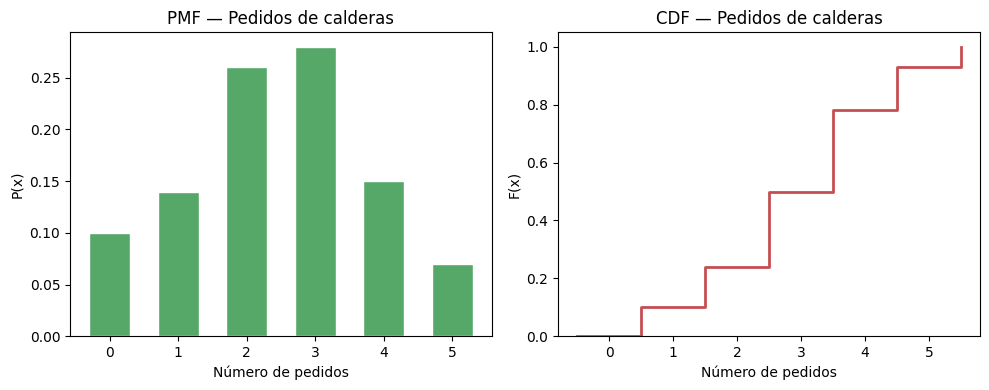

In [19]:
x21 = [0,1,2,3,4,5]
p21 = [0.10,0.14,0.26,0.28,0.15,0.07]
cdf21 = list(np.cumsum(p21))

E21   = sum(x*p for x,p in zip(x21,p21))
V21   = sum(p*(x-E21)**2 for x,p in zip(x21,p21))
std21 = V21**0.5
p_geq3 = sum(p for x,p in zip(x21,p21) if x>=3)

print(f'c) P(X ≥ 3)     = {p_geq3:.2f}')
print(f'd) E(X)          = {E21:.4f}')
print(f'e) Desv. típica  = {std21:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(x21, p21, color='#55A868', edgecolor='white', width=0.6)
axes[0].set_xlabel('Número de pedidos')
axes[0].set_ylabel('P(x)')
axes[0].set_title('PMF — Pedidos de calderas')
axes[0].set_xticks(x21)

axes[1].step([x-0.5 for x in x21]+[x21[-1]+0.5], [0]+cdf21,
             where='post', color='#C44E52', linewidth=2)
axes[1].set_xlabel('Número de pedidos')
axes[1].set_ylabel('F(x)')
axes[1].set_title('CDF — Pedidos de calderas')
axes[1].set_xticks(x21)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Ejercicio 22 — Llamadas de alumnos al profesor

In [20]:
x22 = [0,1,2,3,4,5]
p22 = [0.10,0.15,0.19,0.26,0.19,0.11]

E22   = sum(x*p for x,p in zip(x22,p22))
V22   = sum(p*(x-E22)**2 for x,p in zip(x22,p22))
std22 = V22**0.5

print(f'Media E(X)       = {E22:.4f}')
print(f'Desv. típica σ   = {std22:.4f}')

Media E(X)       = 2.6200
Desv. típica σ   = 1.4750


### Ejercicio 23 — Distribución uniforme continua (oleoducto 2 km)

In [21]:
# X ~ U(0, 2) → f(x) = 0.5, F(x) = x/2
a23, b23 = 0, 2

def F23(x): return max(0, min(1, (x - a23)/(b23 - a23)))

prob23 = F23(1.5) - F23(0.5)

print('CDF: F(x) = x/2  para 0 ≤ x ≤ 2')
print(f'P(0.5 ≤ X ≤ 1.5) = F(1.5) - F(0.5) = {F23(1.5):.2f} - {F23(0.5):.2f} = {prob23:.2f}')

CDF: F(x) = x/2  para 0 ≤ x ≤ 2
P(0.5 ≤ X ≤ 1.5) = F(1.5) - F(0.5) = 0.75 - 0.25 = 0.50


### Ejercicio 24 — Distribución uniforme continua (río 4 km)

c) P(X ≤ 1)           = 0.25
d) P(|X-2| > 1.5)     = 0.25


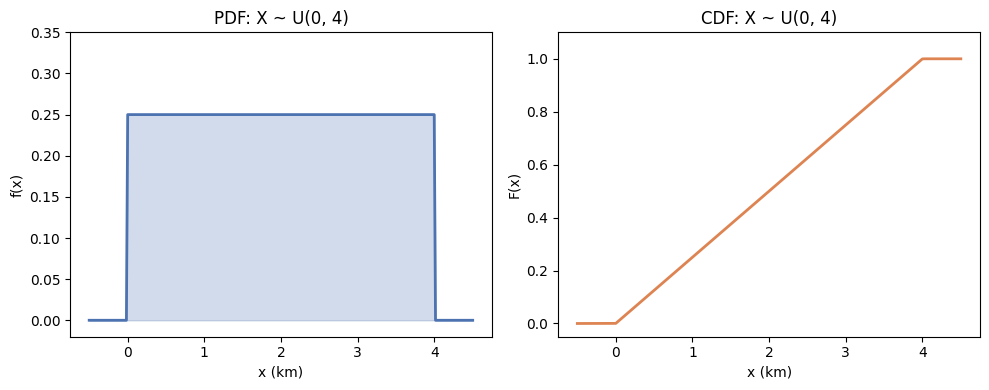

In [22]:
# X ~ U(0, 4) → f(x) = 0.25, F(x) = x/4
a24, b24 = 0, 4

def F24(x): return max(0, min(1, (x - a24)/(b24 - a24)))

pc24 = F24(1)            # P(X ≤ 1)
pd24 = F24(0.5) + (1 - F24(3.5))  # P(|X-2| > 1.5)

print(f'c) P(X ≤ 1)           = {pc24:.2f}')
print(f'd) P(|X-2| > 1.5)     = {pd24:.2f}')

x_vals = np.linspace(-0.5, 4.5, 300)
pdf_vals = np.where((x_vals>=0)&(x_vals<=4), 0.25, 0)
cdf_vals = np.clip(x_vals/4, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# PDF
axes[0].plot(x_vals, pdf_vals, color='#4C72B0', linewidth=2)
axes[0].fill_between(x_vals, pdf_vals, alpha=0.25, color='#4C72B0')
axes[0].set_xlabel('x (km)')
axes[0].set_ylabel('f(x)')
axes[0].set_title('PDF: X ~ U(0, 4)')
axes[0].set_ylim(-0.02, 0.35)

# CDF
axes[1].plot(x_vals, cdf_vals, color='#DD8452', linewidth=2)
axes[1].set_xlabel('x (km)')
axes[1].set_ylabel('F(x)')
axes[1].set_title('CDF: X ~ U(0, 4)')
axes[1].set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()